# Task A – Main Results Evaluation (Extended Metrics)

Loads all 25 saved models (5 datasets × 5 models), evaluates on the held-out **test set**, and produces:

| Output | Description |
|--------|-------------|
| `results/main_results_table.csv` | Core comparison table (RMSE, Accuracy, AUC-ROC, training/inference time) |
| `results/extended_metrics_table.csv` | Extended table: MAE, R², Macro-F1, PR-AUC, Precision, Recall |
| Figures | Bar charts, heatmaps, confusion matrices |

**Extended metrics rationale:**
- **Regression** — RMSE alone is dominated by outliers (Online News target is heavily right-skewed). MAE and R² provide complementary, more robust views.
- **Binary classification (imbalanced)** — Accuracy is misleading when positive-class rate is < 15% (AI4I: 3.4%, Bank Marketing: 11%). Precision, Recall, F1, and PR-AUC directly measure minority-class detection quality.
- **Multiclass** — Macro-F1 weights each of the 7 Dry Bean classes equally, penalising poor performance on rare varieties. The confusion matrix shows which pairs are most frequently confused.

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, roc_auc_score,
    f1_score, precision_score, recall_score,
    average_precision_score,          # PR-AUC
    confusion_matrix, ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)

ROOT      = os.path.dirname(os.path.abspath(""))
DATA_DIR  = os.path.join(ROOT, "data")
MODEL_DIR = os.path.join(ROOT, "saved_models")
RES_DIR   = os.path.join(ROOT, "results")
os.makedirs(RES_DIR, exist_ok=True)
sys.path.insert(0, os.path.join(ROOT, "src"))

print("Root:", ROOT)
print("Datasets:", os.listdir(DATA_DIR))


Root: /home/wuxinzhe76/COMP9417-PR
Datasets: ['bank_marketing', 'online_news', 'dry_bean', 'superconductivity', 'ai4i_maintenance']


In [2]:
DATASET_CONFIG = {
    "dry_bean":          {"task": "multiclass"},
    "ai4i_maintenance":  {"task": "binary"},
    "bank_marketing":    {"task": "binary"},
    "online_news":       {"task": "regression"},
    "superconductivity": {"task": "regression"},
}

MODEL_NAMES = ["xRFM", "XGBoost", "RF", "MLP", "TabNet"]
MODEL_KEYS  = {"xRFM": "xrfm", "XGBoost": "xgb", "RF": "rf",
               "MLP": "mlp", "TabNet": "tabnet"}

def load_test_split(dataset_name):
    base = os.path.join(DATA_DIR, dataset_name, "test")
    X = pd.read_csv(os.path.join(base, "X.csv"))
    y = pd.read_csv(os.path.join(base, "y.csv")).iloc[:, 0]
    return X, y

def transform(meta, X_raw):
    X_np = meta["scaler"].transform(X_raw[meta["num_cols"]]).astype(np.float32)
    if meta["cat_cols"]:
        X_cat = meta["ohe"].transform(X_raw[meta["cat_cols"]]).astype(np.float32)
        X_np  = np.hstack([X_np, X_cat])
    return X_np

def load_model(dataset_name, model_key):
    mdir = os.path.join(MODEL_DIR, dataset_name)
    if model_key == "tabnet":
        from pytorch_tabnet.tab_model import TabNetClassifier, TabNetRegressor
        task     = DATASET_CONFIG[dataset_name]["task"]
        zip_path = os.path.join(mdir, "tabnet", "model.zip")
        if not os.path.exists(zip_path):
            return None
        cls = TabNetRegressor if task == "regression" else TabNetClassifier
        m = cls()
        m.load_model(zip_path)
        return m
    pkl = os.path.join(mdir, f"{model_key}.pkl")
    return joblib.load(pkl) if os.path.exists(pkl) else None

print("Helpers defined.")


Helpers defined.


In [3]:
def evaluate(model, model_key, X_test, y_test, task):
    """
    Returns a dict of all metrics. Unavailable metrics → np.nan.

    Regression  : RMSE, MAE, R²
    Binary      : Accuracy, AUC-ROC, PR-AUC, F1 (macro), Precision (macro), Recall (macro)
    Multiclass  : Accuracy, AUC-ROC (macro-OvR), Macro-F1
    All tasks   : inference latency (µs/sample)
    """
    n = len(X_test)
    res = {k: np.nan for k in ["rmse","mae","r2","accuracy","auc_roc",
                                "pr_auc","f1","precision","recall","infer_us"]}

    # ── Raw predictions + inference time ─────────────────────────────────────
    t0 = time.perf_counter()
    if model_key == "xrfm":
        raw = np.asarray(model.predict(X_test)).ravel()
    elif model_key == "tabnet":
        raw = model.predict(X_test).ravel()
    else:
        raw = model.predict(X_test).ravel()
    res["infer_us"] = (time.perf_counter() - t0) / n * 1e6

    # ── Regression ───────────────────────────────────────────────────────────
    if task == "regression":
        res["rmse"] = float(np.sqrt(mean_squared_error(y_test, raw)))
        res["mae"]  = float(mean_absolute_error(y_test, raw))
        res["r2"]   = float(r2_score(y_test, raw))
        return res

    # ── Classification ───────────────────────────────────────────────────────
    if model_key == "xrfm":
        if task == "binary":
            y_cls   = (raw >= 0.5).astype(int)
            y_score = raw                    # continuous score for AUC
        else:   # multiclass
            y_cls   = np.clip(np.round(raw).astype(int), 0, int(y_test.max()))
            y_score = None
    elif model_key == "tabnet":
        y_cls   = raw.astype(int)
        y_score = model.predict_proba(X_test)
    else:
        y_cls   = raw.astype(int)
        y_score = model.predict_proba(X_test)

    res["accuracy"] = float(accuracy_score(y_test, y_cls))
    res["f1"]       = float(f1_score(y_test, y_cls, average="macro", zero_division=0))
    res["precision"]= float(precision_score(y_test, y_cls, average="macro", zero_division=0))
    res["recall"]   = float(recall_score(y_test, y_cls, average="macro", zero_division=0))

    # AUC-ROC
    if y_score is not None:
        if task == "binary":
            score_1d = y_score[:, 1] if y_score.ndim > 1 else y_score
            res["auc_roc"] = float(roc_auc_score(y_test, score_1d))
            res["pr_auc"]  = float(average_precision_score(y_test, score_1d))
        else:
            res["auc_roc"] = float(roc_auc_score(y_test, y_score,
                                                  multi_class="ovr", average="macro"))
            # PR-AUC not well-defined for multiclass OvR in sklearn
    elif task == "binary" and model_key == "xrfm":
        res["auc_roc"] = float(roc_auc_score(y_test, y_score if y_score is not None else raw))
        res["pr_auc"]  = float(average_precision_score(y_test, raw))

    return res

print("evaluate() defined.")


evaluate() defined.


In [4]:
records = []
extra_records = []   # extended metrics

for dataset_name, cfg in DATASET_CONFIG.items():
    task = cfg["task"]
    print(f"\n{'='*58}")
    print(f"  {dataset_name.upper()}  ({task})")
    print('='*58)

    meta        = joblib.load(os.path.join(MODEL_DIR, dataset_name, "preprocessor.pkl"))
    X_raw, y    = load_test_split(dataset_name)
    X_test      = transform(meta, X_raw)

    le_path = os.path.join(MODEL_DIR, dataset_name, "label_encoder.pkl")
    if task == "multiclass" and os.path.exists(le_path):
        le     = joblib.load(le_path)
        y_test = le.transform(y).astype(int)
    elif task == "regression":
        y_test = np.asarray(y, dtype=np.float64)
    else:
        y_test = np.asarray(y, dtype=int)

    for mname, mkey in MODEL_KEYS.items():
        model = load_model(dataset_name, mkey)
        if model is None:
            print(f"  [{mname}]  not found — skip")
            continue
        try:
            m = evaluate(model, mkey, X_test, y_test, task)

            # ── Core record (original columns) ───────────────────────────────
            rec = {
                "dataset":          dataset_name,
                "task":             task,
                "model":            mname,
                "RMSE":             round(m["rmse"], 4)      if not np.isnan(m["rmse"])      else "—",
                "Accuracy":         round(m["accuracy"], 4)  if not np.isnan(m["accuracy"])  else "—",
                "AUC-ROC":          round(m["auc_roc"], 4)   if not np.isnan(m["auc_roc"])   else "—",
                "Infer_us/sample":  round(m["infer_us"], 4),
            }
            records.append(rec)

            # ── Extended record ───────────────────────────────────────────────
            ext = {
                "dataset":    dataset_name,
                "task":       task,
                "model":      mname,
                "MAE":        round(m["mae"], 4)       if not np.isnan(m["mae"])       else "—",
                "R2":         round(m["r2"], 4)        if not np.isnan(m["r2"])        else "—",
                "Macro_F1":   round(m["f1"], 4)        if not np.isnan(m["f1"])        else "—",
                "PR_AUC":     round(m["pr_auc"], 4)    if not np.isnan(m["pr_auc"])    else "—",
                "Precision":  round(m["precision"], 4) if not np.isnan(m["precision"]) else "—",
                "Recall":     round(m["recall"], 4)    if not np.isnan(m["recall"])    else "—",
            }
            extra_records.append(ext)

            print(f"  [{mname:8s}]  "
                  f"RMSE={rec['RMSE']:<10}  Acc={rec['Accuracy']:<8}  "
                  f"AUC={rec['AUC-ROC']:<8}  F1={ext['Macro_F1']:<8}  "
                  f"MAE={ext['MAE']:<10}  R2={ext['R2']:<8}  "
                  f"PR-AUC={ext['PR_AUC']:<8}  {m['infer_us']:.2f}µs")
        except Exception as e:
            import traceback; traceback.print_exc()
            print(f"  [{mname}]  ERROR — {e}")

print("\n✓ Evaluation complete.")



  DRY_BEAN  (multiclass)


Using soft routing for tree prediction


  [xRFM    ]  RMSE=—           Acc=0.8358    AUC=—         F1=0.8342    MAE=—           R2=—         PR-AUC=—         82.80µs


  [XGBoost ]  RMSE=—           Acc=0.9254    AUC=0.9951    F1=0.9377    MAE=—           R2=—         PR-AUC=—         16.58µs


  [RF      ]  RMSE=—           Acc=0.9214    AUC=0.9928    F1=0.9332    MAE=—           R2=—         PR-AUC=—         57.67µs
  [MLP     ]  RMSE=—           Acc=0.9185    AUC=0.9949    F1=0.9304    MAE=—           R2=—         PR-AUC=—         2.11µs


...

  [RF      ]  RMSE=11127.7091  Acc=—         AUC=—         F1=—         MAE=3373.3242   R2=-0.0261   PR-AUC=—         26.78µs
  [MLP     ]  RMSE=10851.0501  Acc=—         AUC=—         F1=—         MAE=3045.809    R2=0.0243    PR-AUC=—         0.88µs


  [TabNet  ]  RMSE=10835.8475  Acc=—         AUC=—         F1=—         MAE=2913.1389   R2=0.027     PR-AUC=—         21.93µs

  SUPERCONDUCTIVITY  (regression)
Using soft routing for tree prediction


  [xRFM    ]  RMSE=9.8063      Acc=—         AUC=—         F1=—         MAE=5.4169      R2=0.9165    PR-AUC=—         9.39µs
  [XGBoost ]  RMSE=9.5224      Acc=—         AUC=—         F1=—         MAE=5.8692      R2=0.9212    PR-AUC=—         2.14µs


  [RF      ]  RMSE=9.3859      Acc=—         AUC=—         F1=—         MAE=5.3928      R2=0.9235    PR-AUC=—         34.50µs
  [MLP     ]  RMSE=11.5523     Acc=—         AUC=—         F1=—         MAE=7.481       R2=0.8841    PR-AUC=—         1.06µs


  [TabNet  ]  RMSE=12.9696     Acc=—         AUC=—         F1=—         MAE=8.5998      R2=0.8539    PR-AUC=—         24.17µs

✓ Evaluation complete.


In [5]:
results_df = pd.DataFrame(records)
extra_df   = pd.DataFrame(extra_records)

results_df.to_csv(os.path.join(RES_DIR, "main_results_table.csv"),     index=False)
extra_df.to_csv(  os.path.join(RES_DIR, "extended_metrics_table.csv"), index=False)
print("Saved main_results_table.csv")
print("Saved extended_metrics_table.csv\n")

# ── Pretty print core table ───────────────────────────────────────────────────
with pd.option_context("display.max_rows", 50, "display.max_columns", 20,
                       "display.width", 160):
    print(results_df.to_string(index=False))


Saved main_results_table.csv
Saved extended_metrics_table.csv

          dataset       task   model        RMSE Accuracy AUC-ROC  Infer_us/sample
         dry_bean multiclass    xRFM           —   0.8358       —          82.8016
         dry_bean multiclass XGBoost           —   0.9254  0.9951          16.5758
         dry_bean multiclass      RF           —   0.9214  0.9928          57.6731
         dry_bean multiclass     MLP           —   0.9185  0.9949           2.1098
         dry_bean multiclass  TabNet           —   0.9144  0.9941          33.7196
 ai4i_maintenance     binary    xRFM           —    0.978  0.9276           6.2713
 ai4i_maintenance     binary XGBoost           —   0.9855  0.9692           2.3271
 ai4i_maintenance     binary      RF           —   0.9795  0.9651          66.9118
 ai4i_maintenance     binary     MLP           —   0.9755  0.9604           1.0061
 ai4i_maintenance     binary  TabNet           —   0.9745  0.9431          17.6802
   bank_marketing     bi

## Extended Metrics Tables

In [6]:
# ── Regression: RMSE vs MAE vs R² ───────────────────────────────────────────
reg_ext = extra_df[extra_df["task"] == "regression"].copy()
reg_ext["MAE"] = pd.to_numeric(reg_ext["MAE"], errors="coerce")
reg_ext["R2"]  = pd.to_numeric(reg_ext["R2"],  errors="coerce")

reg_core = results_df[results_df["task"] == "regression"][["dataset","model","RMSE"]].copy()
reg_core["RMSE"] = pd.to_numeric(reg_core["RMSE"], errors="coerce")

reg_full = reg_core.merge(reg_ext[["dataset","model","MAE","R2"]], on=["dataset","model"])

print("=== Regression: RMSE / MAE / R² ===")
print(reg_full.to_string(index=False))


=== Regression: RMSE / MAE / R² ===
          dataset   model       RMSE       MAE      R2
      online_news    xRFM 10662.5738 2903.9063  0.0579
      online_news XGBoost 11050.3352 3184.9020 -0.0119
      online_news      RF 11127.7091 3373.3242 -0.0261
      online_news     MLP 10851.0501 3045.8090  0.0243
      online_news  TabNet 10835.8475 2913.1389  0.0270
superconductivity    xRFM     9.8063    5.4169  0.9165
superconductivity XGBoost     9.5224    5.8692  0.9212
superconductivity      RF     9.3859    5.3928  0.9235
superconductivity     MLP    11.5523    7.4810  0.8841
superconductivity  TabNet    12.9696    8.5998  0.8539


In [7]:
# ── Binary classification: Accuracy / AUC-ROC / F1 / Precision / Recall / PR-AUC ──
bin_core = results_df[results_df["task"] == "binary"][
    ["dataset","model","Accuracy","AUC-ROC"]].copy()
bin_ext  = extra_df[extra_df["task"] == "binary"].copy()

bin_full = bin_core.merge(
    bin_ext[["dataset","model","Macro_F1","Precision","Recall","PR_AUC"]],
    on=["dataset","model"]
)
print("=== Binary Classification: Accuracy / AUC-ROC / Macro-F1 / Precision / Recall / PR-AUC ===")
print(bin_full.to_string(index=False))


=== Binary Classification: Accuracy / AUC-ROC / Macro-F1 / Precision / Recall / PR-AUC ===
         dataset   model Accuracy AUC-ROC Macro_F1 Precision  Recall  PR_AUC
ai4i_maintenance    xRFM    0.978  0.9276   0.8047    0.8668  0.7616  0.6858
ai4i_maintenance XGBoost   0.9855  0.9692   0.8723    0.9428  0.8222  0.8218
ai4i_maintenance      RF   0.9795  0.9651   0.7957    0.9334  0.7269  0.7711
ai4i_maintenance     MLP   0.9755  0.9604   0.8199    0.8094  0.8312  0.6763
ai4i_maintenance  TabNet   0.9745  0.9431   0.7306    0.8851  0.6676  0.5436
  bank_marketing    xRFM   0.9067   0.924   0.7246    0.7969  0.6868  0.5956
  bank_marketing XGBoost   0.9085  0.9341   0.7492    0.7908  0.7211  0.6284
  bank_marketing      RF   0.9057  0.9288   0.7212    0.7934  0.6838  0.6167
  bank_marketing     MLP    0.905  0.9224   0.7375    0.7805  0.7092  0.5859
  bank_marketing  TabNet   0.9032  0.9182   0.7493    0.7691  0.7333  0.5706


In [8]:
# ── Multiclass (Dry Bean): Accuracy / AUC-ROC / Macro-F1 ───────────────────
mc_core = results_df[results_df["task"] == "multiclass"][
    ["dataset","model","Accuracy","AUC-ROC"]].copy()
mc_ext  = extra_df[extra_df["task"] == "multiclass"].copy()

mc_full = mc_core.merge(
    mc_ext[["dataset","model","Macro_F1","Precision","Recall"]],
    on=["dataset","model"]
)
print("=== Multiclass (Dry Bean): Accuracy / AUC-ROC / Macro-F1 / Precision / Recall ===")
print(mc_full.to_string(index=False))


=== Multiclass (Dry Bean): Accuracy / AUC-ROC / Macro-F1 / Precision / Recall ===
 dataset   model Accuracy AUC-ROC Macro_F1 Precision  Recall
dry_bean    xRFM   0.8358       —   0.8342    0.8364  0.8605
dry_bean XGBoost   0.9254  0.9951   0.9377    0.9399  0.9357
dry_bean      RF   0.9214  0.9928   0.9332    0.9353  0.9313
dry_bean     MLP   0.9185  0.9949   0.9304    0.9329  0.9284
dry_bean  TabNet   0.9144  0.9941   0.9262    0.9292  0.9235


## Visualisations

Saved -> /home/wuxinzhe76/COMP9417-PR/results/classification_extended_metrics.png


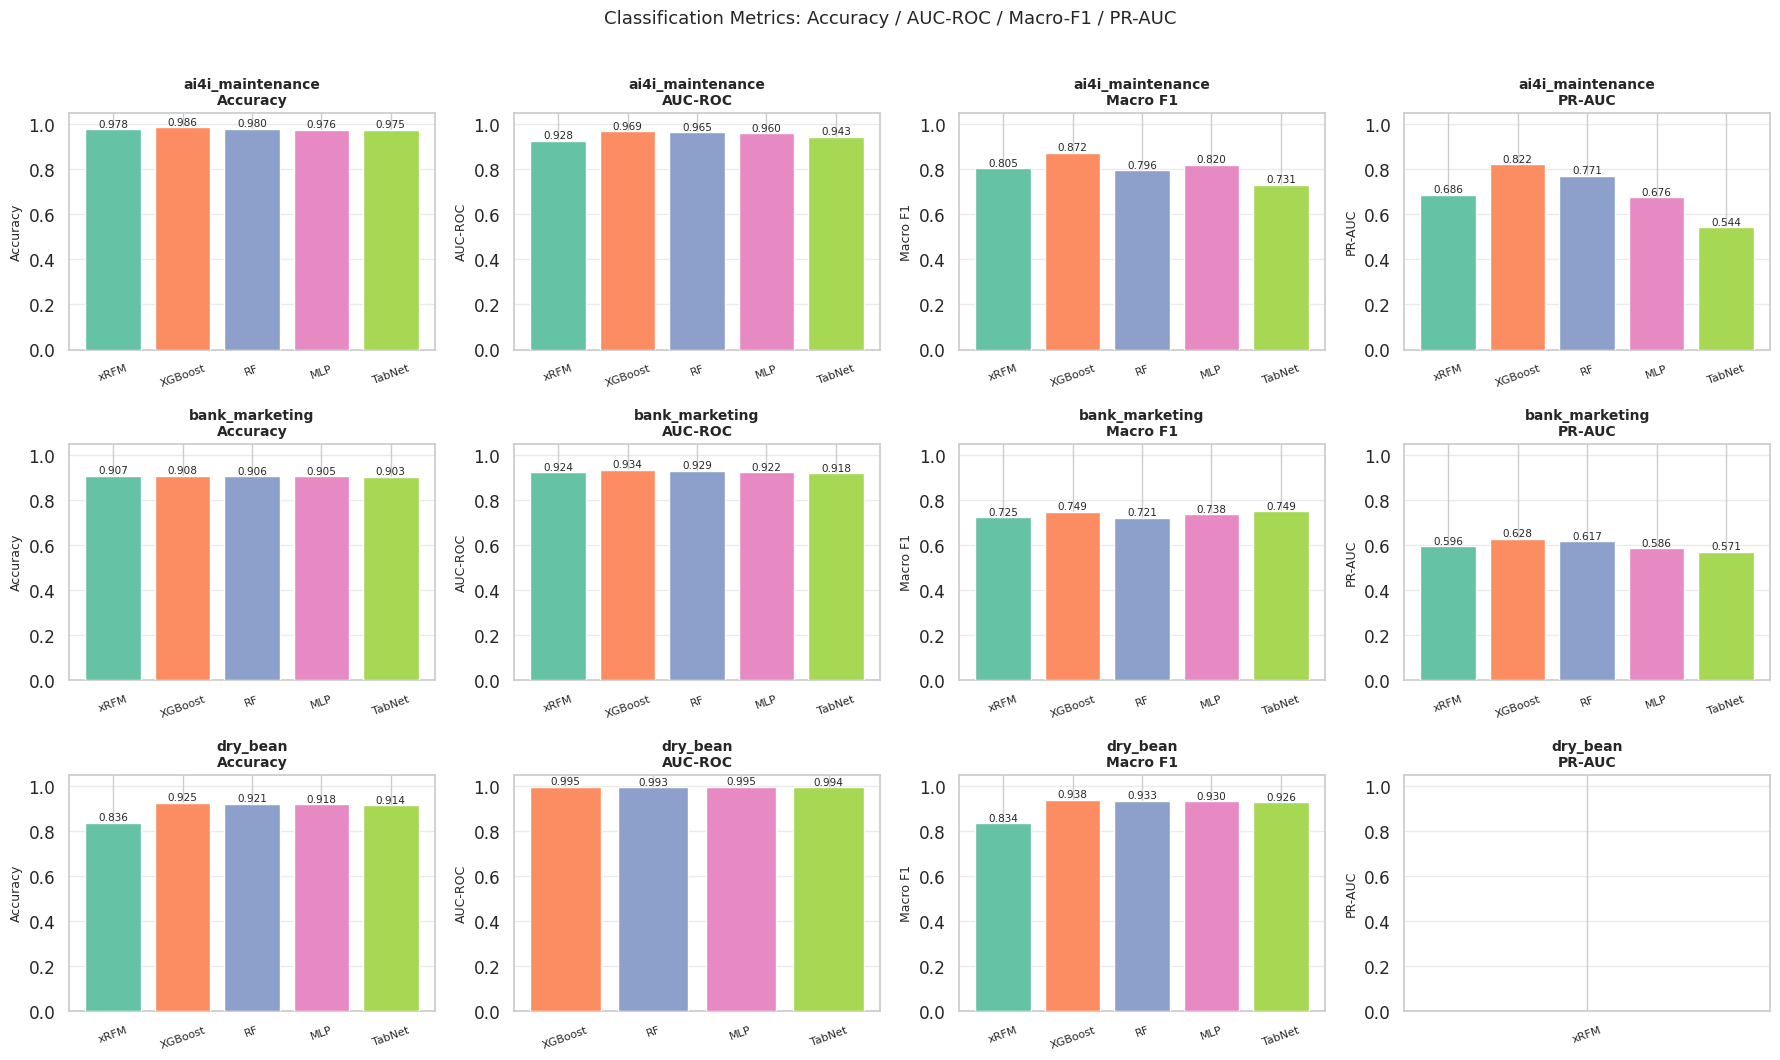

In [9]:
# ── Classification: Accuracy / AUC-ROC / Macro-F1 / PR-AUC (all 3 datasets) ──
clf_df = results_df[results_df["task"].isin(["binary","multiclass"])].copy()
clf_df[["Accuracy","AUC-ROC"]] = clf_df[["Accuracy","AUC-ROC"]].apply(
    pd.to_numeric, errors="coerce"
)
clf_ext = extra_df[extra_df["task"].isin(["binary","multiclass"])].copy()
clf_ext[["Macro_F1","PR_AUC"]] = clf_ext[["Macro_F1","PR_AUC"]].apply(
    pd.to_numeric, errors="coerce"
)
clf_merged = clf_df.merge(clf_ext[["dataset","model","Macro_F1","PR_AUC"]],
                          on=["dataset","model"])

metrics_clf = ["Accuracy", "AUC-ROC", "Macro_F1", "PR_AUC"]
titles_clf  = ["Accuracy", "AUC-ROC", "Macro F1", "PR-AUC"]
datasets_clf = clf_merged["dataset"].unique()
palette     = sns.color_palette("Set2", n_colors=5)

fig, axes = plt.subplots(len(datasets_clf), 4, figsize=(18, 3.5 * len(datasets_clf)),
                         sharey=False)
if len(datasets_clf) == 1:
    axes = axes.reshape(1, -1)

for row_i, ds in enumerate(sorted(datasets_clf)):
    sub = clf_merged[clf_merged["dataset"] == ds]
    for col_j, (metric, title) in enumerate(zip(metrics_clf, titles_clf)):
        ax = axes[row_i, col_j]
        vals = pd.to_numeric(sub[metric], errors="coerce")
        colors = [palette[i] for i in range(len(sub))]
        bars = ax.bar(sub["model"], vals, color=colors, edgecolor="white", zorder=3)
        ax.set_title(f"{ds}\n{title}", fontsize=10, fontweight="bold")
        ax.set_ylim(0, 1.05)
        ax.set_ylabel(title, fontsize=9)
        ax.tick_params(axis="x", labelsize=8, rotation=20)
        ax.yaxis.grid(True, alpha=0.4, zorder=0)
        ax.set_axisbelow(True)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                        f"{v:.3f}", ha="center", fontsize=7.5)

fig.suptitle("Classification Metrics: Accuracy / AUC-ROC / Macro-F1 / PR-AUC",
             fontsize=13, y=1.01)
plt.tight_layout()
out = os.path.join(RES_DIR, "classification_extended_metrics.png")
plt.savefig(out, dpi=200, bbox_inches="tight")
print(f"Saved -> {out}")
plt.show()


Saved -> /home/wuxinzhe76/COMP9417-PR/results/regression_extended_metrics.png


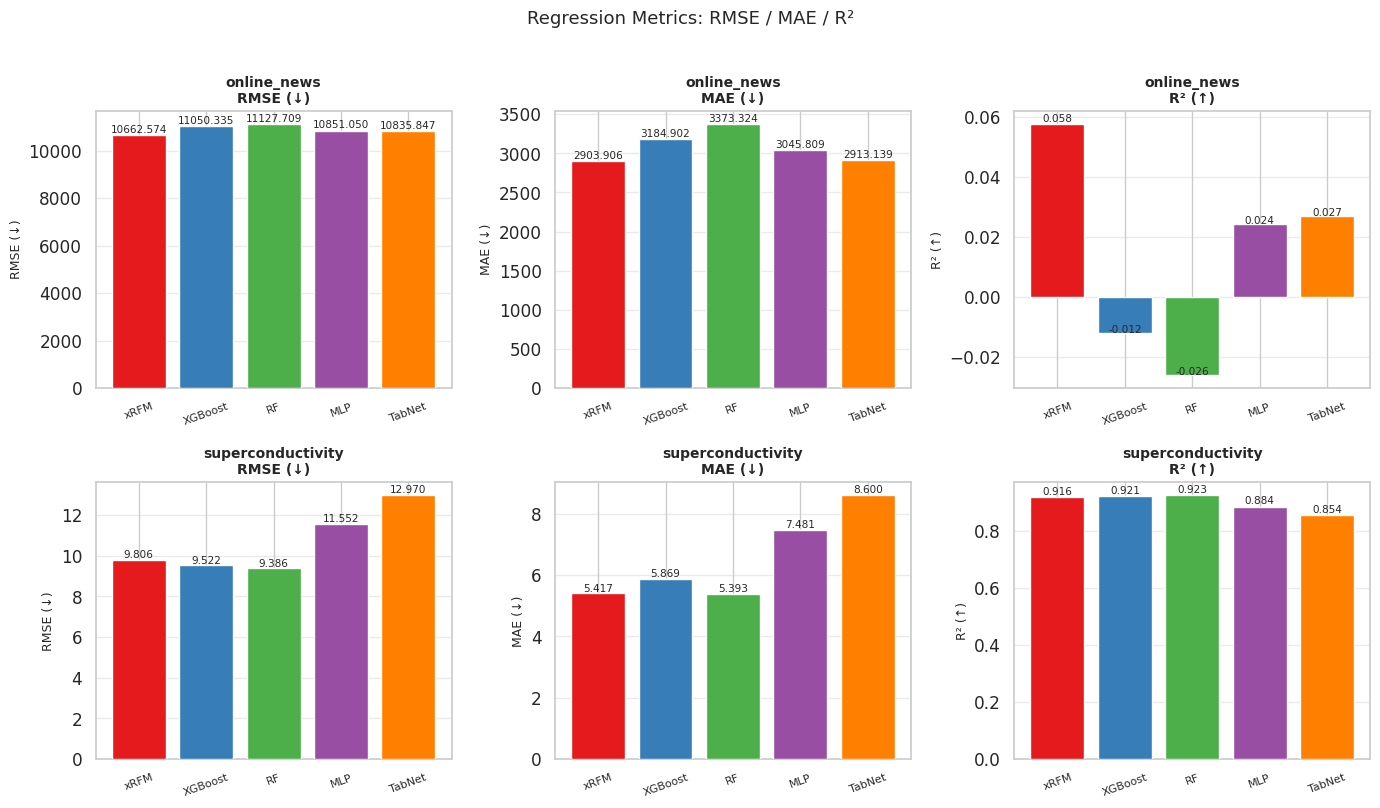

In [10]:
# ── Regression: RMSE / MAE / R² side-by-side ────────────────────────────────
reg_df  = results_df[results_df["task"] == "regression"].copy()
reg_df["RMSE"] = pd.to_numeric(reg_df["RMSE"], errors="coerce")
reg_ext2 = extra_df[extra_df["task"] == "regression"].copy()
reg_ext2[["MAE","R2"]] = reg_ext2[["MAE","R2"]].apply(pd.to_numeric, errors="coerce")
reg_merged = reg_df.merge(reg_ext2[["dataset","model","MAE","R2"]], on=["dataset","model"])

datasets_reg = reg_merged["dataset"].unique()
metrics_reg  = ["RMSE", "MAE", "R2"]
titles_reg   = ["RMSE (↓)", "MAE (↓)", "R² (↑)"]
palette_r    = sns.color_palette("Set1", n_colors=5)

fig, axes = plt.subplots(len(datasets_reg), 3, figsize=(14, 4 * len(datasets_reg)))
if len(datasets_reg) == 1:
    axes = axes.reshape(1, -1)

for row_i, ds in enumerate(sorted(datasets_reg)):
    sub = reg_merged[reg_merged["dataset"] == ds]
    for col_j, (metric, title) in enumerate(zip(metrics_reg, titles_reg)):
        ax = axes[row_i, col_j]
        vals   = sub[metric].values
        colors = [palette_r[i] for i in range(len(sub))]
        bars   = ax.bar(sub["model"], vals, color=colors, edgecolor="white", zorder=3)
        ax.set_title(f"{ds}\n{title}", fontsize=10, fontweight="bold")
        ax.set_ylabel(title, fontsize=9)
        ax.tick_params(axis="x", labelsize=8, rotation=20)
        ax.yaxis.grid(True, alpha=0.4, zorder=0)
        ax.set_axisbelow(True)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    v + abs(v)*0.01,
                    f"{v:.3f}", ha="center", fontsize=7.5)

fig.suptitle("Regression Metrics: RMSE / MAE / R²", fontsize=13, y=1.01)
plt.tight_layout()
out = os.path.join(RES_DIR, "regression_extended_metrics.png")
plt.savefig(out, dpi=200, bbox_inches="tight")
print(f"Saved -> {out}")
plt.show()


### Imbalance Analysis: Precision vs Recall Trade-off

For the two imbalanced binary datasets (AI4I: 3.4% positive, Bank Marketing: 11% positive),
Precision and Recall reveal model behaviour that Accuracy and AUC-ROC can obscure.
A model with high Recall finds most of the minority class (few false negatives),
while high Precision means its positive predictions are trustworthy (few false positives).
F1 is their harmonic mean; PR-AUC summarises the full Precision-Recall curve.

Saved -> /home/wuxinzhe76/COMP9417-PR/results/precision_recall_scatter.png


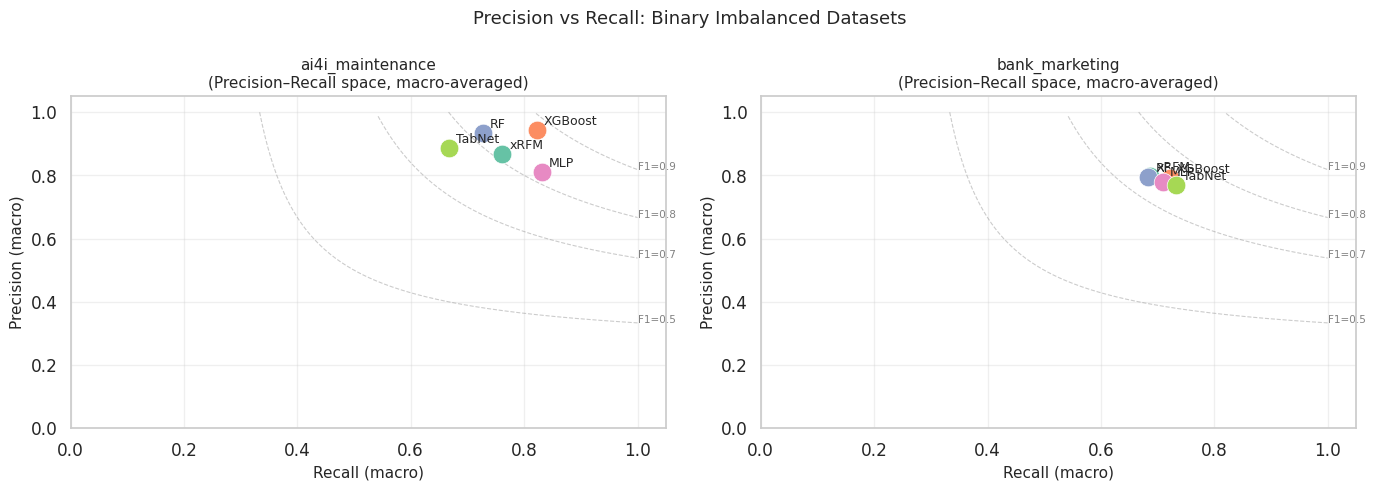

In [11]:
# ── Precision / Recall / F1 scatter for binary tasks ────────────────────────
bin_ext2 = extra_df[extra_df["task"] == "binary"].copy()
for c in ["Macro_F1","Precision","Recall","PR_AUC"]:
    bin_ext2[c] = pd.to_numeric(bin_ext2[c], errors="coerce")

datasets_bin = sorted(bin_ext2["dataset"].unique())
colors_map   = {m: c for m, c in zip(MODEL_NAMES, sns.color_palette("Set2", 5))}

fig, axes = plt.subplots(1, len(datasets_bin), figsize=(7 * len(datasets_bin), 5))
if len(datasets_bin) == 1:
    axes = [axes]

for ax, ds in zip(axes, datasets_bin):
    sub = bin_ext2[bin_ext2["dataset"] == ds]
    for _, row in sub.iterrows():
        p, r, f1 = row["Precision"], row["Recall"], row["Macro_F1"]
        if any(np.isnan(v) for v in [p, r]):
            continue
        ax.scatter(r, p, s=180, color=colors_map.get(row["model"], "grey"),
                   zorder=3, edgecolors="white", linewidths=0.5)
        ax.annotate(row["model"], (r, p),
                    textcoords="offset points", xytext=(5, 4), fontsize=9)

    ax.set_xlabel("Recall (macro)", fontsize=11)
    ax.set_ylabel("Precision (macro)", fontsize=11)
    # Iso-F1 curves
    for f_val in [0.5, 0.7, 0.8, 0.9]:
        r_arr = np.linspace(0.01, 1.0, 200)
        p_arr = f_val * r_arr / (2 * r_arr - f_val + 1e-9)
        mask  = (p_arr > 0) & (p_arr <= 1)
        ax.plot(r_arr[mask], p_arr[mask], "--", color="grey", alpha=0.4, linewidth=0.8)
        ax.text(r_arr[mask][-1], p_arr[mask][-1], f"F1={f_val}", fontsize=7.5,
                color="grey", ha="left")
    ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
    ax.set_title(f"{ds}\n(Precision–Recall space, macro-averaged)", fontsize=11)
    ax.yaxis.grid(True, alpha=0.3); ax.xaxis.grid(True, alpha=0.3)

fig.suptitle("Precision vs Recall: Binary Imbalanced Datasets", fontsize=13)
plt.tight_layout()
out = os.path.join(RES_DIR, "precision_recall_scatter.png")
plt.savefig(out, dpi=200, bbox_inches="tight")
print(f"Saved -> {out}")
plt.show()


### Confusion Matrix: Dry Bean (7-class)

The confusion matrix reveals which of the 7 bean varieties are most frequently confused with each other, providing deeper insight than accuracy alone.

Saved -> /home/wuxinzhe76/COMP9417-PR/results/dry_bean_confusion_matrices.png


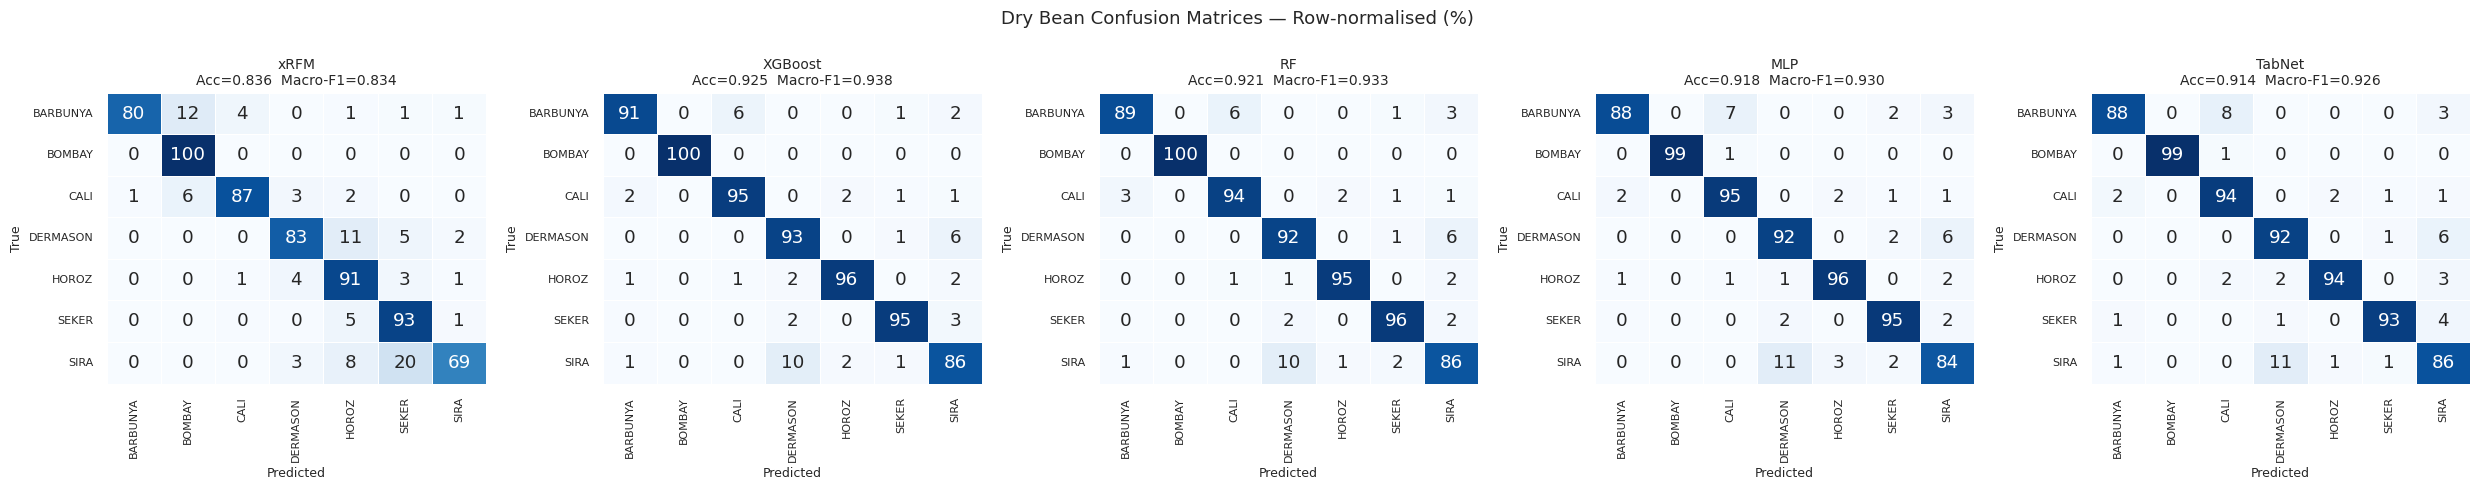

In [12]:
# ── Confusion matrices for all 5 models on Dry Bean ────────────────────────
import io, contextlib

meta_db   = joblib.load(os.path.join(MODEL_DIR, "dry_bean", "preprocessor.pkl"))
le_db     = joblib.load(os.path.join(MODEL_DIR, "dry_bean", "label_encoder.pkl"))
X_raw_db, y_db = load_test_split("dry_bean")
X_db      = transform(meta_db, X_raw_db)
y_db_enc  = le_db.transform(y_db).astype(int)
class_names = le_db.classes_

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, (mname, mkey) in zip(axes, MODEL_KEYS.items()):
    model = load_model("dry_bean", mkey)
    if model is None:
        ax.set_title(f"{mname}\n(not found)"); ax.axis("off"); continue

    with contextlib.redirect_stdout(io.StringIO()):
        if mkey == "xrfm":
            raw = np.asarray(model.predict(X_db)).ravel()
            y_p = np.clip(np.round(raw).astype(int), 0, 6)
        elif mkey == "tabnet":
            y_p = model.predict(X_db).ravel().astype(int)
        else:
            y_p = model.predict(X_db).ravel().astype(int)

    cm = confusion_matrix(y_db_enc, y_p, labels=list(range(len(class_names))))
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm_pct, ax=ax, annot=True, fmt=".0f",
                xticklabels=class_names, yticklabels=class_names,
                cmap="Blues", cbar=False, linewidths=0.4)
    acc = accuracy_score(y_db_enc, y_p)
    f1  = f1_score(y_db_enc, y_p, average="macro", zero_division=0)
    ax.set_title(f"{mname}\nAcc={acc:.3f}  Macro-F1={f1:.3f}", fontsize=10)
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("True", fontsize=9)
    ax.tick_params(axis="both", labelsize=8)

fig.suptitle("Dry Bean Confusion Matrices — Row-normalised (%) ", fontsize=13)
plt.tight_layout()
out = os.path.join(RES_DIR, "dry_bean_confusion_matrices.png")
plt.savefig(out, dpi=180, bbox_inches="tight")
print(f"Saved -> {out}")
plt.show()


## Original Charts (Core Metrics)

Saved -> /home/wuxinzhe76/COMP9417-PR/results/classification_accuracy_auc.png


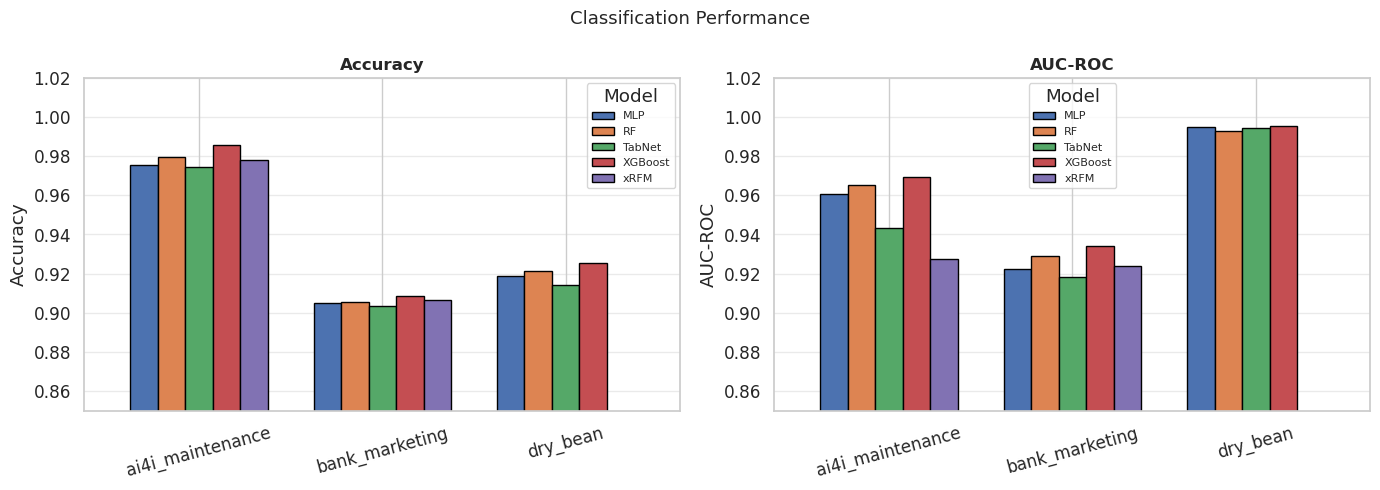

In [13]:
# ── Accuracy and AUC-ROC bar charts ─────────────────────────────────────────
clf_df2 = results_df[results_df["task"].isin(["binary","multiclass"])].copy()
clf_df2[["Accuracy","AUC-ROC"]] = clf_df2[["Accuracy","AUC-ROC"]].apply(
    pd.to_numeric, errors="coerce"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ["Accuracy", "AUC-ROC"]):
    pivot = clf_df2.pivot(index="dataset", columns="model", values=metric)
    pivot.plot(kind="bar", ax=ax, edgecolor="black", width=0.75)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_ylabel(metric); ax.set_xlabel("")
    ax.set_ylim(0.85, 1.02); ax.legend(title="Model", fontsize=8)
    ax.tick_params(axis="x", rotation=15)
    ax.yaxis.grid(True, alpha=0.4); ax.set_axisbelow(True)

fig.suptitle("Classification Performance", fontsize=13)
plt.tight_layout()
out = os.path.join(RES_DIR, "classification_accuracy_auc.png")
plt.savefig(out, dpi=200, bbox_inches="tight")
print(f"Saved -> {out}")
plt.show()


Saved -> /home/wuxinzhe76/COMP9417-PR/results/regression_rmse.png


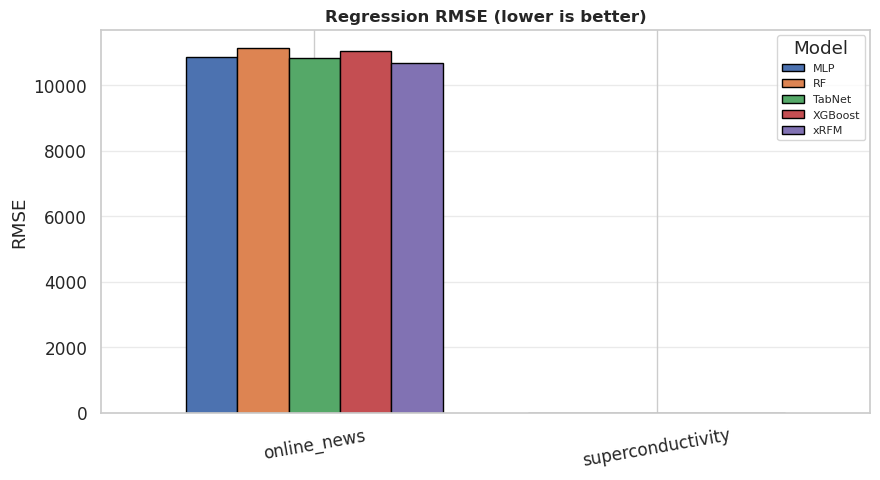

In [14]:
# ── RMSE bar chart for regression ───────────────────────────────────────────
reg_df2 = results_df[results_df["task"] == "regression"].copy()
reg_df2["RMSE"] = pd.to_numeric(reg_df2["RMSE"], errors="coerce")

pivot_rmse = reg_df2.pivot(index="dataset", columns="model", values="RMSE")

fig, ax = plt.subplots(figsize=(9, 5))
pivot_rmse.plot(kind="bar", ax=ax, edgecolor="black", width=0.75)
ax.set_title("Regression RMSE (lower is better)", fontsize=12, fontweight="bold")
ax.set_ylabel("RMSE"); ax.set_xlabel("")
ax.tick_params(axis="x", rotation=10)
ax.yaxis.grid(True, alpha=0.4); ax.set_axisbelow(True)
ax.legend(title="Model", fontsize=8)

plt.tight_layout()
out = os.path.join(RES_DIR, "regression_rmse.png")
plt.savefig(out, dpi=200, bbox_inches="tight")
print(f"Saved -> {out}")
plt.show()


Saved -> /home/wuxinzhe76/COMP9417-PR/results/inference_time_heatmap.png


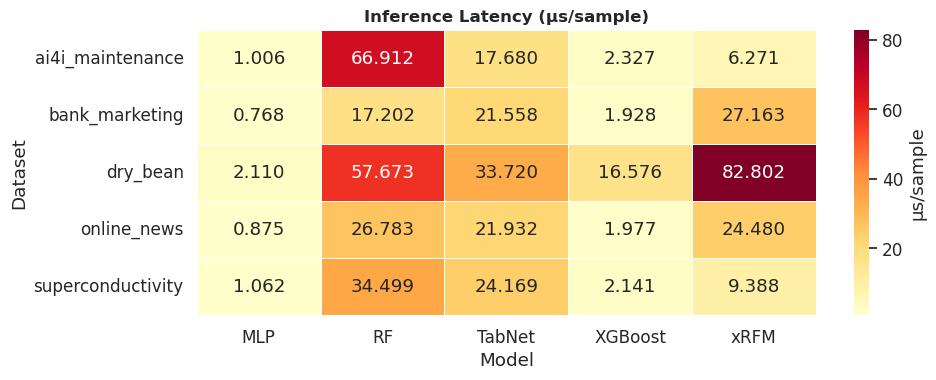

In [15]:
# ── Inference time heatmap ───────────────────────────────────────────────────
infer_df = results_df.copy()
infer_df["Infer_us/sample"] = pd.to_numeric(infer_df["Infer_us/sample"], errors="coerce")
pivot_infer = infer_df.pivot(index="dataset", columns="model", values="Infer_us/sample")

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot_infer, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax,
            linewidths=0.5, cbar_kws={"label": "µs/sample"})
ax.set_title("Inference Latency (µs/sample)", fontsize=12, fontweight="bold")
ax.set_xlabel("Model"); ax.set_ylabel("Dataset")

plt.tight_layout()
out = os.path.join(RES_DIR, "inference_time_heatmap.png")
plt.savefig(out, dpi=200, bbox_inches="tight")
print(f"Saved -> {out}")
plt.show()


In [16]:
# ── xRFM performance summary ─────────────────────────────────────────────────
print("=" * 65)
print("  xRFM EXTENDED PERFORMANCE SUMMARY")
print("=" * 65)
xrfm_r = results_df[results_df["model"] == "xRFM"]
xrfm_e = extra_df[extra_df["model"] == "xRFM"]
xrfm_all = xrfm_r.merge(xrfm_e, on=["dataset","task","model"])

for _, row in xrfm_all.iterrows():
    if row["task"] == "regression":
        print(f"  {row['dataset']:25s}  RMSE={row['RMSE']:<10}  "
              f"MAE={row['MAE']:<10}  R²={row['R2']}")
    else:
        print(f"  {row['dataset']:25s}  Acc={row['Accuracy']:<8}  "
              f"AUC={row['AUC-ROC']:<8}  F1={row['Macro_F1']:<8}  "
              f"PR-AUC={row['PR_AUC']}")
print("=" * 65)

print("\\nAll output files:")
for fn in ["main_results_table.csv", "extended_metrics_table.csv",
           "classification_accuracy_auc.png", "classification_extended_metrics.png",
           "regression_rmse.png", "regression_extended_metrics.png",
           "precision_recall_scatter.png", "dry_bean_confusion_matrices.png",
           "inference_time_heatmap.png"]:
    fpath = os.path.join(RES_DIR, fn)
    status = "✓" if os.path.exists(fpath) else "✗ missing"
    print(f"  {status}  {fn}")


  xRFM EXTENDED PERFORMANCE SUMMARY
  dry_bean                   Acc=0.8358    AUC=—         F1=0.8342    PR-AUC=—
  ai4i_maintenance           Acc=0.978     AUC=0.9276    F1=0.8047    PR-AUC=0.6858
  bank_marketing             Acc=0.9067    AUC=0.924     F1=0.7246    PR-AUC=0.5956
  online_news                RMSE=10662.5738  MAE=2903.9063   R²=0.0579
  superconductivity          RMSE=9.8063      MAE=5.4169      R²=0.9165
\nAll output files:
  ✓  main_results_table.csv
  ✓  extended_metrics_table.csv
  ✓  classification_accuracy_auc.png
  ✓  classification_extended_metrics.png
  ✓  regression_rmse.png
  ✓  regression_extended_metrics.png
  ✓  precision_recall_scatter.png
  ✓  dry_bean_confusion_matrices.png
  ✓  inference_time_heatmap.png
